In [1]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import os

def plot(path):
    df_results = pd.read_csv(path)

    successful_results = df_results[df_results['success']].copy()

    pivot_mmd = successful_results.pivot_table(values='mmd_score', 
                                            index='num_bins', 
                                            columns='g', 
                                            aggfunc='mean')

    pivot_time = successful_results.pivot_table(values='execution_time_sec', 
                                            index='num_bins', 
                                            columns='g', 
                                            aggfunc='mean')

    X_mmd = pivot_mmd.columns.values
    Y_mmd = pivot_mmd.index.values
    X_mmd, Y_mmd = np.meshgrid(X_mmd, Y_mmd)
    Z_mmd = pivot_mmd.values

    X_time = pivot_time.columns.values
    Y_time = pivot_time.index.values
    X_time, Y_time = np.meshgrid(X_time, Y_time)
    Z_time = pivot_time.values

    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'surface'}, {'type': 'surface'}]],
        subplot_titles=('MMD Score vs g vs num_bins', 'Execution Time vs g vs num_bins')
    )

    fig.add_trace(
        go.Surface(z=Z_mmd, x=pivot_mmd.columns, y=pivot_mmd.index, 
                colorscale='Viridis', colorbar=dict(x=0.45, y=0.5)),
        row=1, col=1
    )

    fig.add_trace(
        go.Surface(z=Z_time, x=pivot_time.columns, y=pivot_time.index, 
                colorscale='Plasma', colorbar=dict(x=1.0, y=0.5)),
        row=1, col=2
    )

    min_mmd_idx = np.unravel_index(np.nanargmin(Z_mmd), Z_mmd.shape)
    min_g = pivot_mmd.columns[min_mmd_idx[1]]
    min_bins = pivot_mmd.index[min_mmd_idx[0]]
    min_mmd = Z_mmd[min_mmd_idx]

    min_time_idx = np.unravel_index(np.nanargmin(Z_time), Z_time.shape)
    min_time_g = pivot_time.columns[min_time_idx[1]]
    min_time_bins = pivot_time.index[min_time_idx[0]]
    min_time = Z_time[min_time_idx]

    fig.update_layout(
        title_text='Comparison: MMD Score vs Execution Time',
        scene=dict(
            xaxis_title='Parameter g',
            yaxis_title='Number of Bins',
            zaxis_title='MMD Score',
            yaxis_type='log'
        ),
        scene2=dict(
            xaxis_title='Parameter g',
            yaxis_title='Number of Bins',
            zaxis_title='Time (seconds)',
            yaxis_type='log'
        ),
        width=1400,
        height=700
    )

    fig.add_trace(
        go.Scatter3d(
            x=[min_g], y=[min_bins], z=[min_mmd],
            mode='markers', marker=dict(size=6, color='red'),
            name=f'Best MMD: {min_mmd:.4f}',
            showlegend=True
        ),
        row=1, col=1
    )

    fig.add_annotation(
        x=0.25, y=0.05, xref="paper", yref="paper",
        text=f"Best MMD: g={min_g}, bins={min_bins}, MMD={min_mmd:.6f}",
        showarrow=False,
        font=dict(color="red")
    )

    fig.add_annotation(
        x=0.75, y=0.05, xref="paper", yref="paper",
        text=f"Best Time: g={min_time_g}, bins={min_time_bins}, Time={min_time:.2f}s",
        showarrow=False,
        font=dict(color="green")
    )

    fig.show()
    return min_g, min_bins

In [2]:
import os
import pandas as pd

folders = [
    "results/adult",
    "results/blobs",
    "results/german",
    "results/heloc",
    "results/compas",
    "results/heart",
    "results/gaussian",
]
all_files = []
for folder in folders:
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.endswith(".csv") and "_gaussian" in file:
                all_files.append(os.path.join(root, file))

# Read all CSVs and concatenate into a single DataFrame
all_data = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

import re

all_data = []

for path in all_files:
    df = pd.read_csv(path)
    
    match = re.search(r'_(\d+)_', os.path.basename(path))
    if match:
        dataset_size = int(match.group(1))
    else:
        dataset_size = None
    
    df['dataset_size'] = dataset_size
    
    all_data.append(df)

all_data_df = pd.concat(all_data, ignore_index=True)

all_data_df['compression_ratio'] = all_data_df['compressed_size'] / all_data_df['dataset_size']
all_data_df.head()

,g,num_bins,execution_time_sec,compressed_size,mmd_score,success,dataset_size,compression_ratio
0,0,1,0.010835,128,0.000159,True,20000,0.0064
1,1,1,0.048932,256,0.000041,True,20000,0.0128
2,2,1,0.120280,512,0.000016,True,20000,0.0256
3,3,1,0.345300,1024,0.000007,True,20000,0.0512
4,4,1,1.159027,2048,0.000005,True,20000,0.1024


/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_19163/2574521325.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_19163/2574521325.py:21: UserWarning: 
The palette list has fewer values (1) than needed (56) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


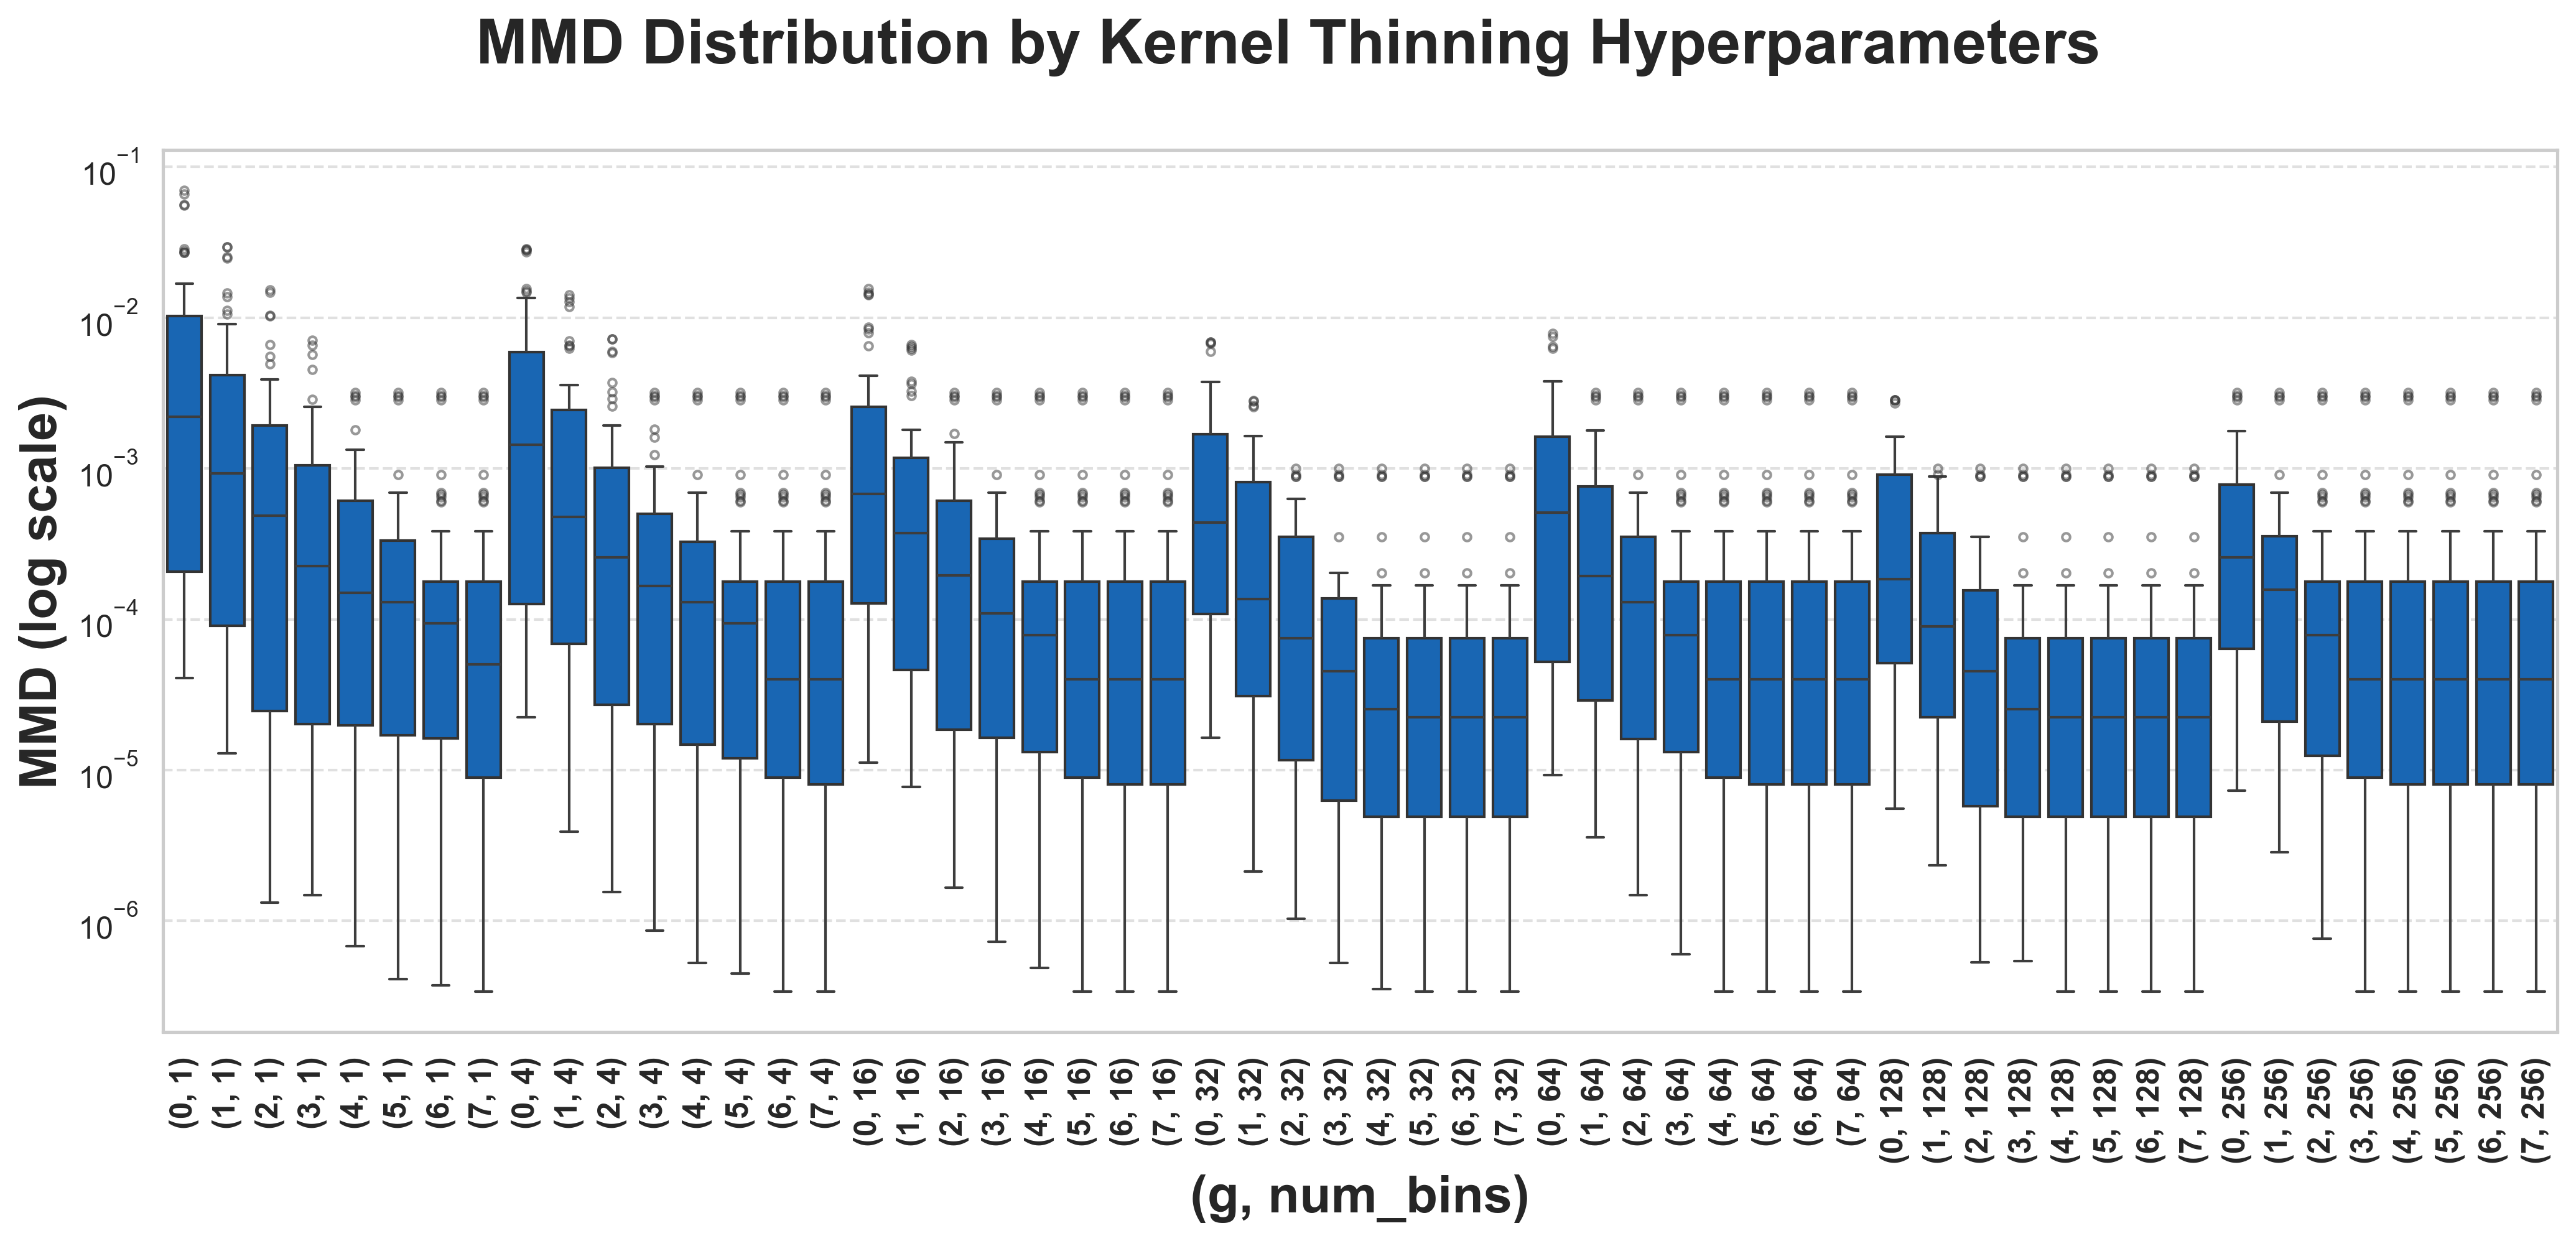

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
all_data_df["g_num_bins"] = all_data_df.apply(
    lambda row: f"({int(row['g'])}, {int(row['num_bins'])})", axis=1
)

order = (
    all_data_df[["g_num_bins", "g", "num_bins"]]
    .drop_duplicates()
    .sort_values(["num_bins", "g"])
    ["g_num_bins"]
    .tolist()
)
palette = sns.light_palette("#0066cc", n_colors=2)[1:] 
fig, ax = plt.subplots(1, 1, figsize=(14, 7), dpi=300)

sns.boxplot(
    data=all_data_df,
    x="g_num_bins",
    y="mmd_score",
    order=order,
    palette=palette,
    width=0.8,
    showfliers=True, 
    flierprops=dict(
        marker="o", markersize=3, linestyle="none",
        markeredgecolor="#333333", alpha=0.5
    ),
    linewidth=1.0,
    ax=ax
)

for patch in ax.patches:
    patch.set_edgecolor("#333333")

ax.set_yscale("log")
ax.set_xlabel("(g, num_bins)", fontsize=20, fontweight="bold")
ax.set_ylabel("MMD (log scale)", fontsize=20, fontweight="bold")

ax.grid(True, axis="y", linestyle="--", alpha=0.6)
ax.grid(False, axis="x")

ax.tick_params(axis="x", rotation=90, labelsize=12)
for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")

plt.suptitle(
    "MMD Distribution by Kernel Thinning Hyperparameters",
    fontsize=24,
    fontweight="bold",
    y=0.95
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()